<a href="https://colab.research.google.com/github/AzaniFatturFadhika/2025_pengolahan_citra_TI2B/blob/main/Jobsheet04_SegmentasiGambar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# JOBSHEET 04: SEGMENTASI GAMBAR

- Nama: Azani Fattur Fadhika
- NIM: 4.33.23.1.05
- Kelas: TI-2B

## Praktikum 1. Segmentasi Menggunakan Thresholding Global dan Otsu

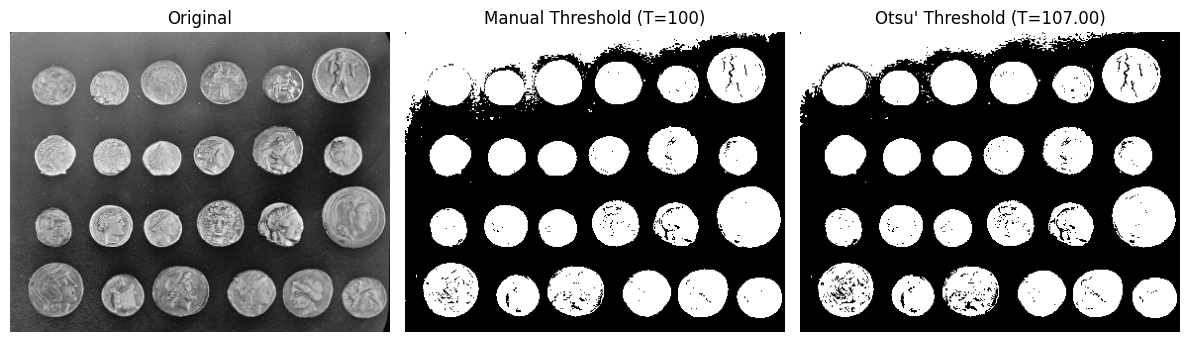

Nilai threshold Otsu yang ditentukan: 107


In [ ]:
import matplotlib.pyplot as plt

from skimage import data, filters, img_as_ubyte
from skimage.color import rgb2gray

# 1. Memuat citra (coins)
image_coins = data.coins()

# 2. Thresholding Global (Manual)
# Tentukan nilai ambang manual, misal 100
thresh_manual = 100
binary_manual = image_coins > thresh_manual

# 3. Tresholding Otsu
thresh_otsu = filters.threshold_otsu(image_coins)
binary_otsu = image_coins > thresh_otsu

# 4. Visualisasi Hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('Original')
ax[0].axis('off')

ax[1].imshow(binary_manual, cmap=plt.cm.gray)
ax[1].set_title(f'Manual Threshold (T={thresh_manual})')
ax[1].axis('off')

ax[2].imshow(binary_otsu, cmap=plt.cm.gray)
ax[2].set_title(f'Otsu\' Threshold (T={thresh_otsu:.2f})')
ax[2].axis('off')

plt.tight_layout()
plt.show()

# Menampilkan nilai threshold Otsu
print(f"Nilai threshold Otsu yang ditentukan: {thresh_otsu}")

## Praktikum 2. Segmentasi Menggunakan Region Growing (Contoh Sederhana)

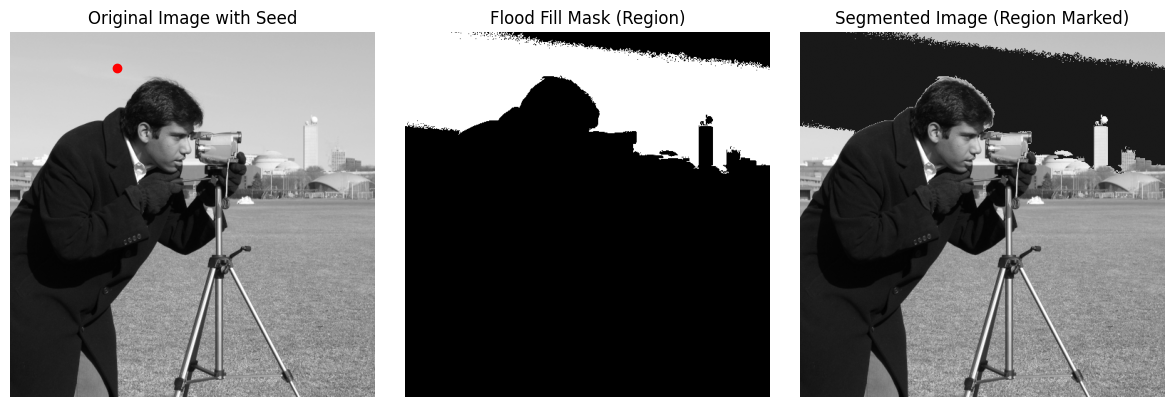

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, segmentation, color

# 1. Memuat citra (camera)
image_camera = data.camera()

# 2. Tentukan titik 'seed' (banih)
# Misal, kita pilih tiitk di area langit (misal, koordinat y=50, x=150)
seed_point = (50, 150)

# 3. Terapkan algoritma flood fill (mirip region growing)
# 'tolerance' menentukan seberapa besar perbedaan intensitas yang diizinkan
flood_mask = segmentation.flood(image_camera, seed_point, tolerance=10)

# 4. Buat citra tersegmrntasi (tandai region dengan warna putih)
segmented_image = np.copy(image_camera)
segmented_image[flood_mask] = 25 # Tandai region dengan warna putih

# 5. Visualisasi Hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_camera, cmap=plt.cm.gray)
ax[0].plot(seed_point[1], seed_point[0], 'ro') # Tandai seed point
ax[0].set_title('Original Image with Seed')
ax[0].axis('off')

ax[1].imshow(flood_mask, cmap=plt.cm.gray)
ax[1].set_title('Flood Fill Mask (Region)')
ax[1].axis('off')

ax[2].imshow(segmented_image, cmap=plt.cm.gray)
ax[2].set_title('Segmented Image (Region Marked)')
ax[2].axis('off')

plt.tight_layout()
plt.show()

## Praktikum 3. Segmentasi Citra Berwarna Menggunakan K-Means Clustering

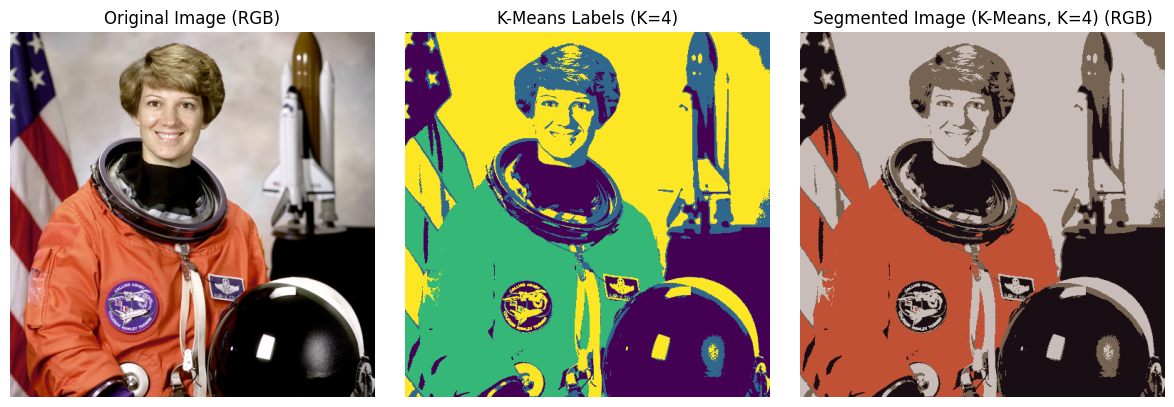

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, io
from sklearn.cluster import KMeans
from skimage.color import rgb2lab, lab2rgb
import warnings

# 1. Memuat citra berwarna (astronaut)
image_astro = data.astronaut()
# Konversi ke float untuk perhitungan
image_astro_float = image_astro.astype(float) / 255.0

# 2. Reshape citra menjadi array pixel [jumlah_pixel, jumlah_fitur]
# Fitur bisa RGB atau Lab. Ruang warna Lab seringkali lebih baik untuk persepsi warna.
# Konversi ke Lab
image_lab = rgb2lab(image_astro_float)
rows, cols, dims = image_lab.shape
pixel_features = image_lab.reshape(rows * cols, dims)

# 3. Terapkan K-Means Clustering
# Tentukan jumlah cluster (segmen) yang diinginkan, misal k=4
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10) # n_init = 'auto' jika versi skelarn baru
# Hiding FutureWarnings related to default value of n_init with warnings.catch_warning():
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)

# 4. Reshape label kembali ke bentuk citra
segmented_labels = pixel_labels.reshape(rows, cols)

# 5. Buat  itrs tersegmentasi (warnai setiap segmen dengan warna rata-rata cluster)
segmented_image_kmeans = np.zeros_like(image_lab)
centers_lab = kmeans.cluster_centers_
for k in range(n_clusters):
    # Dapatkan piksel yang termasuk klaster k
    cluster_pixels = (pixel_labels == k)
    # Isi piksel tersebut di citra baru dengan warna pusat klaster k
    # Perlu reshape kembali cluster_pixels ke bentuk citra
    mask_k = cluster_pixels.reshape(rows, cols)
    segmented_image_kmeans[mask_k] = centers_lab[k]

# Konversi kembali ke RGB untuk ditampilakan
segmentasi_image_rgb = lab2rgb(segmented_image_kmeans)

# 6. Visualisasi Hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_astro)
ax[0].set_title('Original Image (RGB)')
ax[0].axis('off')

# Menampilkan label cluster
ax[1].imshow(segmented_labels, cmap='viridis') # cmap bisa diganti
ax[1].set_title(f'K-Means Labels (K={n_clusters})')
ax[1].axis('off')

# Menampilkan citra hasil segmentasi K-Means
ax[2].imshow(segmentasi_image_rgb)
ax[2].set_title(f'Segmented Image (K-Means, K={n_clusters}) (RGB)')
ax[2].axis('off')

plt.tight_layout()
plt.show()

## Praktikum 4. Segmentasi Berbasis Tepi Menggunakan Watershed

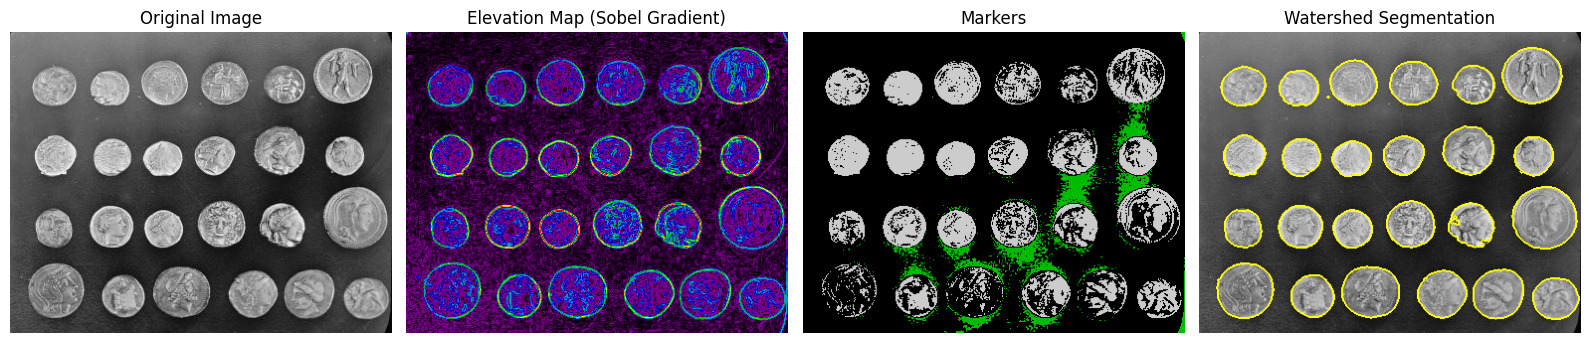

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, morphology, measure
from scipy import ndimage as ndi

# 1. Memuat citra (coins)
image_coins = data.coins()

# 2. Hitung gradien citra (sebagai 'topografi')
elevation_map = filters.sobel(image_coins)

# 3. Tentukan marker (penanda awal untuk setiap cekungan/objek)
# Kita bisa menggunakan thresholding untuk mendapatkan marker kasar
markers = np.zeros_like(image_coins)
markers[image_coins < 30] = 1 # Marker untuk latar belakang
markers[image_coins > 150] = 2 # Marker untuk objek (koin)

# Atau gunakan marker dari local maxima (lebih canggih)
# from skimage.feature import peak_local_max
# image_max = ndi.maximum_filter(image_coins, size=20, mode='constant')
# coordinates = peak_local_max(image_coins, min_distance=20)
# markers = np.zeros(image_coins.shape, dtype=bool)
# markers[tuple(coordinates.T)] = True
# markers = measure.label(markers)

# 4. Terapkan algoritma Watershed
segmentation_watershed = segmentation.watershed(elevation_map, markers)

# Warnai hasil segmentasi untuk visualisasi
segmented_colored = segmentation.mark_boundaries(image_coins, segmentation_watershed)

# 5. Visualisasi Hasil
fig, axes = plt.subplots(ncols=4, figsize=(16, 4), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(elevation_map, cmap=plt.cm.nipy_spectral)
ax[1].set_title('Elevation Map (Sobel Gradient)')
ax[1].axis('off')

ax[2].imshow(markers, cmap=plt.cm.nipy_spectral)
ax[2].set_title('Markers')
ax[2].axis('off')

ax[3].imshow(segmented_colored)
ax[3].set_title('Watershed Segmentation')
ax[3].axis('off')

plt.tight_layout()
plt.show()

## Praktikum 5. Perbandingan Visual Hasil Segmentasi

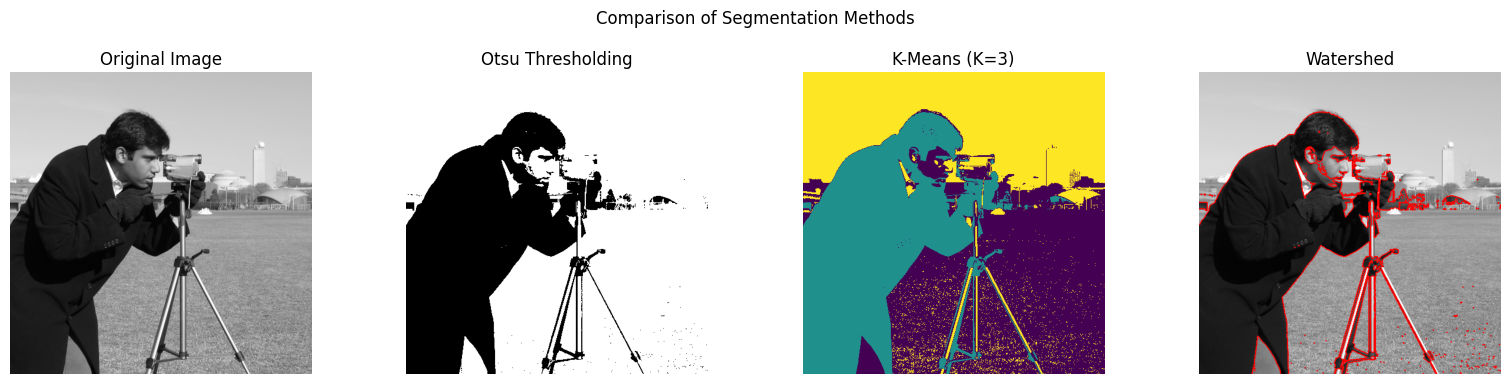

In [ ]:
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, img_as_float, color
from sklearn.cluster import KMeans
import numpy as np
import warnings

# 1. Pilih satu citra untuk perbandingan (camera)
image = data.camera()
image_float = img_as_float(image)

# 2. Lakukan beberapa metode segmentasi
# a) Otsu Thresholding
thresh_otsu = filters.threshold_otsu(image)
binary_otsu = image > thresh_otsu

# b) K-Means (misal K=3)
# Reshape untuk K-Means (1 fitur: intensitas)
rows, cols = image.shape
pixel_features = image_float.reshape(rows * cols, 1)
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)
with warnings.catch_warnings():
  warnings.simplefilter("ignore")
  pixel_labels = kmeans.fit_predict(pixel_features)
segmented_kmeans_labels = pixel_labels.reshape(rows, cols)

# c) Watershed (gunakan marker sederhana dari Otsu)
elevation_map = filters.sobel(image)
markers = np.zeros_like(image)
markers[image < thresh_otsu] = 1
markers[image > thresh_otsu] = 2
segmentation_watershed = segmentation.watershed(elevation_map, markers)

# 3. Visualisasi Perbandingan
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap=plt.cm.gray)
ax[1].set_title('Otsu Thresholding')
ax[1].axis('off')

ax[2].imshow(segmented_kmeans_labels, cmap='viridis') # Gunakan cmapberbeda untuk label
ax[2].set_title(f'K-Means (K={n_clusters})')
ax[2].axis('off')

# Gunakan mark_boundaries untuk Watershed agar lebih jelas
segmented_watershed_colored = segmentation.mark_boundaries(image_float,segmentation_watershed, color=(1,0,0)) # Batas merah
ax[3].imshow(segmented_watershed_colored)
ax[3].set_title('Watershed')
ax[3].axis('off')

plt.suptitle('Comparison of Segmentation Methods')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
plt.show()

## Penugasan

### 3. Eksperimen Thresholding: Terapkan metode thresholding Otsu pada citra data.page().
- Apakah hasilnya memuaskan?
- Mengapa?
- Coba gunakan metode thresholding lain yang ada
di skimage.filters (misalnya, threshold_local atau threshold_yen)
- dan bandingkan
hasilnya.

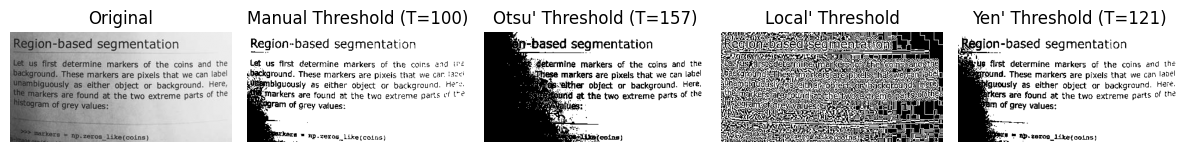

Nilai threshold Otsu yang ditentukan: 157
Nilai threshold Local yang ditentukan: [[136.0541015  137.03248452 138.96763358 ... 239.         239.
  239.        ]
 [139.96751548 138.98913246 137.99976379 ... 239.         239.
  239.        ]
 [141.9458985  139.97826492 137.01098565 ... 239.         239.
  239.        ]
 ...
 [ 47.2386135   54.00047241  50.06532335 ... 225.         225.
  225.        ]
 [ 63.847382    67.6851956   64.71815254 ... 225.         225.
  225.        ]
 [ 62.97909164  60.08611361  57.14033321 ... 225.         225.
  225.        ]]
Nilai threshold Yen yang ditentukan: 121


In [ ]:
import matplotlib.pyplot as plt

from skimage import data, filters, img_as_ubyte
from skimage.color import rgb2gray

# 1. Memuat citra (coins)
image_coins = data.page()

# 2. Thresholding Global (Manual)
# Tentukan nilai ambang manual, misal 100
thresh_manual = 100
binary_manual = image_coins > thresh_manual

# 3. Tresholding
# - Otsu
thresh_otsu = filters.threshold_otsu(image_coins)
binary_otsu = image_coins > thresh_otsu
# - Otsu
thresh_local = filters.threshold_local(image_coins)
binary_local = image_coins > thresh_local
# - Otsu
thresh_yen = filters.threshold_yen(image_coins)
binary_yen = image_coins > thresh_yen

# 4. Visualisasi Hasil
fig, axes = plt.subplots(ncols=5, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('Original')
ax[0].axis('off')

ax[1].imshow(binary_manual, cmap=plt.cm.gray)
ax[1].set_title(f'Manual Threshold (T={thresh_manual})')
ax[1].axis('off')

ax[2].imshow(binary_otsu, cmap=plt.cm.gray)
ax[2].set_title(f'Otsu\' Threshold (T={thresh_otsu})')
ax[2].axis('off')

ax[3].imshow(binary_local, cmap=plt.cm.gray)
ax[3].set_title('Local\' Threshold')
ax[3].axis('off')

ax[4].imshow(binary_yen, cmap=plt.cm.gray)
ax[4].set_title(f'Yen\' Threshold (T={thresh_yen})')
ax[4].axis('off')

plt.tight_layout()
plt.show()

# Menampilkan nilai threshold Otsu
print(f"Nilai threshold Otsu yang ditentukan: {thresh_otsu}")
print(f"Nilai threshold Local yang ditentukan: {thresh_local}")
print(f"Nilai threshold Yen yang ditentukan: {thresh_yen}")

### Cari satu contoh citra sederhana dari internet (misalnya, citra buah-buahan dengan latarbelakang polos, atau citra sel mikroskop).
- Terapkan setidaknya tiga metode segmentasi yang berbeda (misalnya, Otsu, K-Means, dan Watershed) pada citra tersebut.
- Bandingkan hasilnya secara visual dan diskusikan metode mana yang paling cocok untuk citra pilihan
Anda,
- serta jelaskan alasannya

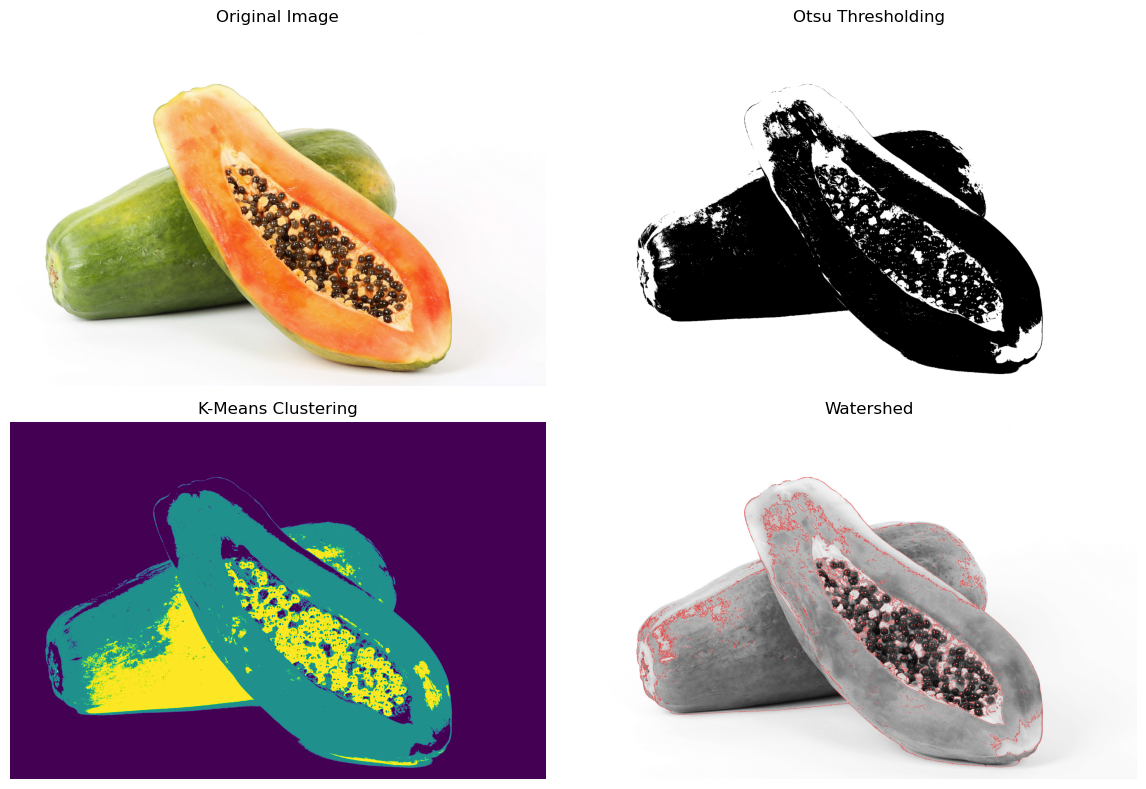

In [ ]:
import matplotlib.pyplot as plt
from skimage import io, filters, segmentation, color, img_as_float
from skimage.color import rgb2gray
from sklearn.cluster import KMeans
import numpy as np
import warnings

# 1. Memuat gambar 'pepaya.jpeg' dari folder 'gambar'
image_path = 'gambar/pepaya.jpeg'  # Sesuaikan path jika berbeda
image_pepaya = io.imread(image_path)

# Konversi gambar ke float untuk perhitungan
image_pepaya_float = img_as_float(image_pepaya)

# 2. Segmentasi menggunakan metode Otsu
image_gray = rgb2gray(image_pepaya_float)  # Konversi ke grayscale
thresh_otsu = filters.threshold_otsu(image_gray)
binary_otsu = image_gray > thresh_otsu

# 3. Segmentasi menggunakan K-Means
rows, cols = image_gray.shape
pixel_features = image_gray.reshape(rows * cols, 1)  # Reshape untuk K-Means
n_clusters = 3  # Jumlah cluster
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)
segmented_kmeans = pixel_labels.reshape(rows, cols)

# 4. Segmentasi menggunakan Watershed
elevation_map = filters.sobel(image_gray)  # Gradien citra
markers = np.zeros_like(image_gray)
markers[image_gray < thresh_otsu] = 1
markers[image_gray > thresh_otsu] = 2
segmentation_watershed = segmentation.watershed(elevation_map, markers)
segmented_watershed_colored = segmentation.mark_boundaries(image_gray, segmentation_watershed, color=(1, 0, 0))  # Batas merah

# 5. Visualisasi hasil segmentasi
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
ax = axes.ravel()

ax[0].imshow(image_pepaya)
ax[0].set_title("Original Image")
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap=plt.cm.gray)
ax[1].set_title("Otsu Thresholding")
ax[1].axis('off')

ax[2].imshow(segmented_kmeans, cmap='viridis')
ax[2].set_title("K-Means Clustering")
ax[2].axis('off')

ax[3].imshow(segmented_watershed_colored)
ax[3].set_title("Watershed")
ax[3].axis('off')

plt.tight_layout()
plt.show()